#Notebook: Logistic regression
**Autora:** Yadsiri Vazquez\
**Materia:** Clasificación inteligente de datos  

---
##1.1  Fundamentos de la técnica
La Regresión Logística es un algoritmo de clasificación supervisada utilizado para predecir clases binarias o múltiples, su propósito es clasificar observaciones en categorías.

La regresión logística nos ayuda a encontrar el mejor fit, su funcion logistica que mejor se ajusta para describir la relacion entre "X" y "Y".

Su propósito principal es modelar la relación entre variables predictoras "X" y una variable objetivo categórica "Y", estimando probabilidades mediante una función logística.

En un caso clásico en donde "Y" es binario, las clases se etiquetan como 1 (clase positiva) y 0 (clase negativa). La salida del modelo representa P(Y=1|X) la probabilidad de que la observación pertenezca a la clase 1 dado sus características.

Es uno de los clasificadores más usados por su:
- Interpretabilidad
- Bajo costo computacional
- Eficiencia para problemas linealmente separables

##1.2 Modelo matematico

La regresión logística modela la probabilidad de pertenecer a la clase 1 mediante la función sigmoide, esta modela la probabilidad de pertenecer a una clase como:

P( y = 1 ∣ x )= 1 / 1 + e⁻ʷᵗˣ
P( y = 0 ∣ x )= 1 / 1 + e⁻ʷᵗˣ

- wᵀx = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ (combinación lineal)

- e es la base del logaritmo natural

- w son los pesos del modelo

La función objetivo a minimizar es la entropía cruzada binaria.
Fúncion de pérdida:
y =  L(w) = -Σ [yᵢ log ŷᵢ + (1-yᵢ) log(1- ŷᵢ)]

- yᵢ = etiqueta real (0 o 1)

- ŷᵢ = probabilidad predicha P(y=1|x)

- Σ = sumatoria sobre todos los ejemplos


##1.3  Descripción de la librería, clases, funciones en su respectiva sección

Librerías utilizadas:
1. Numpy: Para manejo de arreglos numéricos.
2. Pandas: En este tutorial, se usa para crear un DataFrame con las características del dataset Iris y agregar la columna de la clase o etiqueta de cada flor
3. Matplotlib (matplotlib.pyplot) librería para la creación de gráficos en 2D.  Aquí se utiliza para mostrar gráficamente la distribución de las características del dataset y los resultados del modelo.
4. Seaborn (seaborn) Está construida sobre Matplotlib y proporciona  gráficos estadísticos mas visuales.
5. Scikit-learn (sklearn): Proporciona herramientas para realizar tareas de clasificación, regresión, clustering, reducción de dimensionalidad, entre otras.

Funciones:
1. from sklearn.datasets import load_iris: trae el dataset Iris.
- iris.data: características
- iris.target: clase
- iris.feature_names: nombres de las caracteristicas
- iris.target_names:  nombres de las clases

2. from sklearn.model_selection import train_test_split: División de datos
- train_test_split(X, y, test_size=0.3, random_state=42, stratify=y): Divide el dataset en 80% entrenamiento, 20% prueba
3. from sklearn.preprocessing import StandardScaler: El escalado
- scaler.fit_transform(X_train): calcula media y desviación estandar
- scaler.transform(X_test): Normaliza el conjunto de prueba usando los valores calculados solo con entrenamiento.

4. modelo = LogisticRegression(): Crea el modelo de regresión logística

- modelo.fit(X_train, y_train): Entrena el modelo usando:

    X_train: características
    
    y_train: clases
5. modelo.predict(X_test): Predice la clase (0 o 1) para los datos de prueba.
6. confusion_matrix(y_test, y_pred): muestra el número de aciertos y errores por clase.

7. accuracy_score(y_test, y_pred): devuelve la proporción de predicciones correctas (precisión global del modelo).

A continuación se implementa la Regresión Logística usando el dataset Iris, pero reduciendo la clasificación a dos clases (binaria), ya que como se mencionó, Logistic Regression clásica opera de manera más clara en un ejemplo binario.

Resumen estadístico del dataset:

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         100.000000        100.000000         100.000000   
mean            5.471000          3.099000           2.861000   
std             0.641698          0.478739           1.449549   
min             4.300000          2.000000           1.000000   
25%             5.000000          2.800000           1.500000   
50%             5.400000          3.050000           2.450000   
75%             5.900000          3.400000           4.325000   
max             7.000000          4.400000           5.100000   

       petal width (cm)      target  
count        100.000000  100.000000  
mean           0.786000    0.500000  
std            0.565153    0.502519  
min            0.100000    0.000000  
25%            0.200000    0.000000  
50%            0.800000    0.500000  
75%            1.300000    1.000000  
max            1.800000    1.000000  


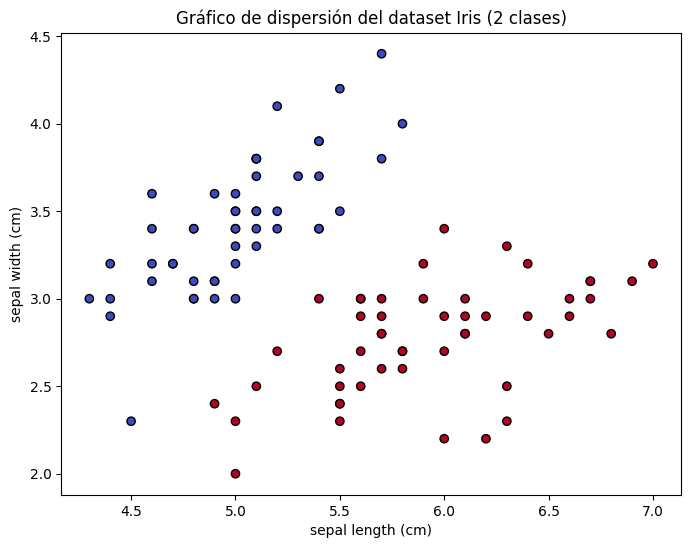

In [94]:
# 1.4.1 Preprocesamiento

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

# dataset Iris
iris = load_iris()
X = iris.data #Caracteristicas
y = iris.target #clase


# Usamos solamente las clases 0 y 1 (Setosa y Versicolor)
mask = y < 2 #crea un array de True/False, esta filtra las filas donde mask es True en ambos
X = X[mask]
y = y[mask]

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

print("Resumen estadístico del dataset:\n")
print(df.describe())

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title('Gráfico de dispersión del dataset Iris (2 clases)')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

In [95]:
# División para entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizamos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenamiento, creamos modelo
modelo = LogisticRegression()

#Entrenamiento, se guardan los datos
modelo.fit(X_train, y_train)

print("Modelo Logistic Regression entrenado")

Modelo Logistic Regression entrenado


In [96]:
## 1.4.2 Prediction
def clasificar_patron(patron):
    ##Aqui se recibe un vector con las características y regresa la clase que predice
    patron = scaler.transform([patron])
    pred = modelo.predict(patron)[0]
    clase = iris.target_names[pred]
    print(f"La flor pertenece a la clase predicha: {clase}")


#Ejemplo: predecir una flor
nuevo_patron = [5.2, 3.8, 2.1, 1.3]
clasificar_patron(nuevo_patron)

La flor pertenece a la clase predicha: setosa


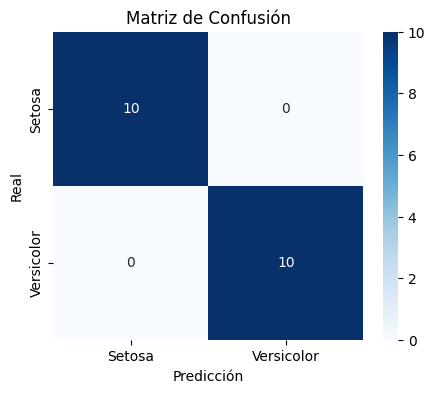


🔎 Accuracy del modelo: 1.0


In [97]:
# 1.4.3 Model Evaluation

# Las predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Matriz de confusión y exactitud
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Setosa", "Versicolor"],
            yticklabels=["Setosa", "Versicolor"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print(f"\n🔎 Accuracy del modelo: {round(acc, 4)}")

La matriz de confusión es una tabla que compara las clases reales del conjunto de prueba contra las clases predichas por el modelo. Cada celda indica cuántos ejemplos fueron clasificados correctamente o incorrectamente.
Se interpreta de la siguiente manera:
- TN: Cantidad de flores clase 0 clasificadas correctamente como clase 0.
- TP:  Cantidad de flores clase 1 clasificadas correctamente como clase 1.
- FP: Errores donde la flor era clase 0 pero el modelo dijo clase 1.
- FN:  Errores donde la flor era clase 1 pero el modelo dijo clase 0.

En este caso todas las predicciones fueron correctas.

Con accuracy, esta mide que tan bien se clasificó el modelo general, son las predicciones correctas entre el total de predicciones. En este caso tuvimos un accuracy de 1, lo que indica que es un modelo con un buen rendimiento.

## 2. Interpretación y ejecución

Este notebook puede ejecutarse sin errores tanto en Jupyter como en Google Colab, ya que solo requiere las librerías:  
numpy, `matplotlib, y scikit-learn.

Para ejecutarlo en Colab:
1. Abre [https://colab.research.google.com](https://colab.research.google.com)
2. Sube este notebook o crea uno nuevo.
3. Ejecuta las celdas secuencialmente.

##3. Referencias Bibliográficas
- IBM. (2025, 17 noviembre). Logistic Regression. https://www.ibm.com/think/topics/logistic-regression
- GeeksforGeeks. (2025, 11 julio). Logistic Regression using Python. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/
- Scikit-Learn Documentation. https://scikit-learn.org/stable/modules/neighbors.html
- Chat GPT